In [5]:
import cv2
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
from dataclasses import dataclass
import os
import matplotlib
from scipy.signal import find_peaks


# 1 Preprocessing

In [17]:
@dataclass
class Component:
    """Class to store connected component information"""
    bbox: Tuple[int, int, int, int]  # x, y, w, h
    centroid: Tuple[float, float]
    area: int
    contour_length: int


In [7]:
image_path = "test1.png"
max_iterations = 10
kfill_threshold = 5

In [9]:
def kfill(binary_image, k=5, max_iterations=10):
    """
    Implement the kFill filter for noise reduction in binary document images.
    This is the Will filter mentioned in the paper.
    
    Args:
        binary_image (numpy.ndarray): Binary image (1 for foreground, 0 for background).
        k (int): Window size parameter (must be odd).
        max_iterations (int): Maximum number of iterations to perform.
        
    Returns:
        numpy.ndarray: Filtered binary image.
    """
    # Ensure k is odd
    if k % 2 == 0:
        k = k + 1
    
    # Create a copy of the image
    filtered_image = binary_image.copy()
    
    iteration = 0
    changes_made = True
    
    # Continue until no changes or max iterations reached
    while changes_made and iteration < max_iterations:
        changes_made = False
        iteration += 1
        
        # Perform ON-fill and OFF-fill sub-iterations
        for fill_value in [1, 0]:  # 1 for ON-fill, 0 for OFF-fill
            height, width = filtered_image.shape
            
            # Create a copy to store changes for this sub-iteration
            temp_image = filtered_image.copy()
            
            # Process each pixel
            for y in range(k//2, height - k//2):
                for x in range(k//2, width - k//2):
                    # Extract window
                    window = filtered_image[y - k//2 : y + k//2 + 1, x - k//2 : x + k//2 + 1]
                    
                    # Define core and neighborhood
                    core = window[1:-1, 1:-1]
                    
                    # Only proceed if all core values are opposite of fill_value
                    if fill_value == 1 and np.any(core == 1):
                        continue
                    if fill_value == 0 and np.any(core == 0):
                        continue
                    
                    # Extract neighborhood (perimeter of window)
                    neighborhood = np.concatenate([
                        window[0, :],                # Top row
                        window[-1, :],               # Bottom row
                        window[1:-1, 0],             # Left column (without corners)
                        window[1:-1, -1]             # Right column (without corners)
                    ])
                    
                    # Calculate n (number of ON or OFF pixels in neighborhood)
                    if fill_value == 1:
                        n = np.sum(neighborhood == 1)  # Count ON pixels
                    else:
                        n = np.sum(neighborhood == 0)  # Count OFF pixels
                    
                    # Calculate c (number of connected groups in neighborhood)
                    # We need to analyze the neighborhood as a circular list
                    expanded_neighborhood = np.concatenate([neighborhood, neighborhood[0:1]])
                    c = 0
                    for i in range(len(neighborhood)):
                        if expanded_neighborhood[i] != expanded_neighborhood[i+1]:
                            c += 1
                    c = c // 2  # Each transition is counted twice (ON->OFF and OFF->ON)
                    
                    # Calculate r (number of corner pixels that are ON or OFF)
                    corners = [window[0, 0], window[0, -1], window[-1, 0], window[-1, -1]]
                    if fill_value == 1:
                        r = sum(1 for corner in corners if corner == 1)
                    else:
                        r = sum(1 for corner in corners if corner == 0)
                    
                    # Apply kFill condition: (c = 1) AND [(n > 3k - 4) OR (n = 3k - 4) AND r = 2]
                    if (c == 1) and ((n > 3*k - 4) or ((n == 3*k - 4) and (r == 2))):
                        # Fill the core
                        temp_image[y - k//2 + 1 : y + k//2, x - k//2 + 1 : x + k//2] = fill_value
                        changes_made = True
            
            # Update filtered_image with the results of this sub-iteration
            filtered_image = temp_image.copy()
    
    return filtered_image


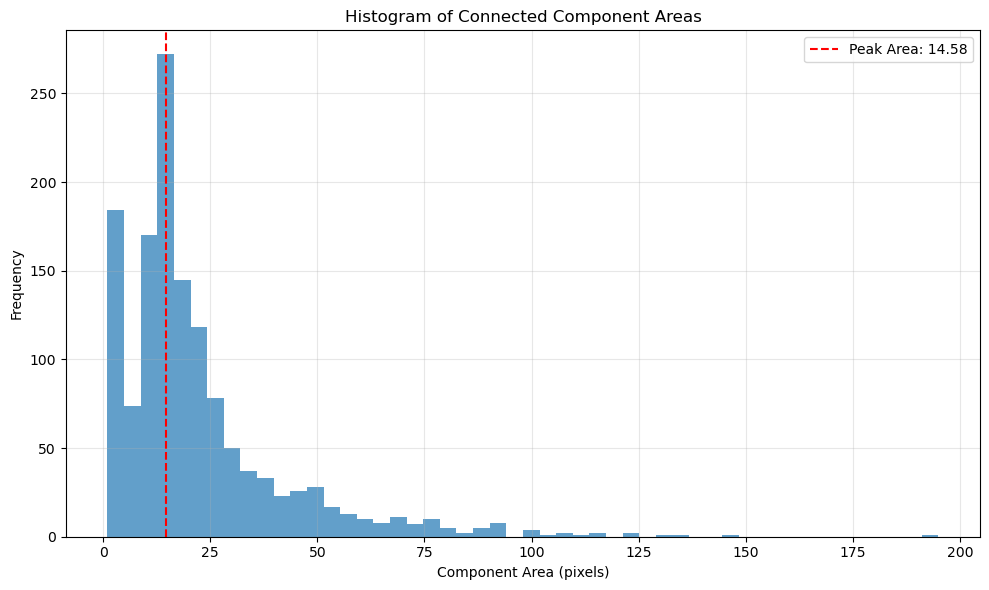

Total components: 1350
Filtered components (area between 3 and 43.74): 1037
Peak area from histogram: 14.58


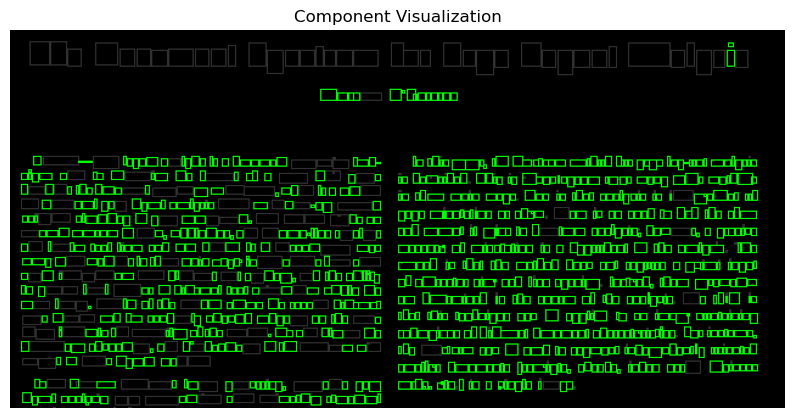

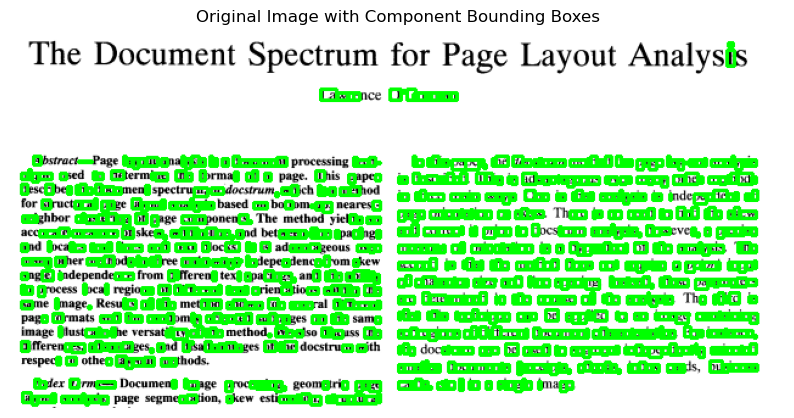

In [7]:
def find_and_filter_components(binary_image):
    """
    Find connected components, calculate their areas, plot a histogram,
    and filter based on the peak of the histogram.
    
    Args:
        binary_image (numpy.ndarray): Binary image (1 for foreground, 0 for background).
        
    Returns:
        list: List of filtered Component objects
        numpy.ndarray: Visualization image with components
    """
    # Make sure the binary image is in the format OpenCV expects (uint8, values 0 or 255)
    binary_for_cv = (binary_image * 255).astype(np.uint8)
    
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_for_cv, connectivity=8)
    
    # Create Component objects for each connected component (skip the background label 0)
    components = []
    for i in range(1, num_labels):
        # Extract bounding box data
        x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        centroid = (centroids[i, 0], centroids[i, 1])
        
        # Instead of contour length, we'll use perimeter
        # Create a mask for this component
        component_mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_length = cv2.arcLength(contours[0], True) if contours else 0
        
        # Create Component object
        components.append(Component(bbox=(x, y, w, h), centroid=centroid, area=area, contour_length=contour_length))
    
    # Extract areas for histogram
    areas = [comp.area for comp in components]
    
    # Plot histogram of component areas
    plt.figure(figsize=(10, 6))
    hist, bin_edges = np.histogram(areas, bins=50)
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), alpha=0.7, align='edge')
    plt.xlabel('Component Area (pixels)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Connected Component Areas')
    
    # Find the peak of the histogram
    peak_bin_index = np.argmax(hist)
    peak_area = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2
    plt.axvline(peak_area, color='r', linestyle='--', label=f'Peak Area: {peak_area:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Set minimum and maximum area thresholds
    min_area = 3  # As per requirements
    max_area = 3 * peak_area  # 3 times the peak area
    
    # Filter components based on area criteria
    filtered_components = [comp for comp in components if min_area <= comp.area <= max_area]
    
    # Create a visualization image
    visualization = np.zeros((binary_image.shape[0], binary_image.shape[1], 3), dtype=np.uint8)
    
    # Draw original components in gray
    for comp in components:
        x, y, w, h = comp.bbox
        cv2.rectangle(visualization, (x, y), (x + w, y + h), (50, 50, 50), 1)
    
    # Draw filtered components in green with labels
    for i, comp in enumerate(filtered_components):
        x, y, w, h = comp.bbox
        cv2.rectangle(visualization, (x, y), (x + w, y + h), (0, 255, 0), 1)
        # cv2.putText(visualization, f'{i+1}', (int(comp.centroid[0]), int(comp.centroid[1])), 
        #             cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
    
    # Display basic stats
    print(f"Total components: {len(components)}")
    print(f"Filtered components (area between {min_area} and {max_area:.2f}): {len(filtered_components)}")
    print(f"Peak area from histogram: {peak_area:.2f}")
    
    return filtered_components, visualization

# Assuming you have already run the previous code to get the binary image
# Let's modify your code to incorporate the component analysis:

image = cv2.imread(image_path)

# Convert the image to grayscale first
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Otsu's thresholding on the grayscale image
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert if needed (assuming text is black)
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)
    
# Convert to binary format (0 and 1)
binary = (binary > 0).astype(np.uint8)

# Apply the Will filter (kFill) for noise reduction
filtered_binary = kfill(binary, k=kfill_threshold, max_iterations=max_iterations)

# Find and filter components
filtered_components, visualization = find_and_filter_components(filtered_binary)

# Display the visualization
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
plt.title('Component Visualization')
plt.axis('off')
plt.show()


filtered_image = np.zeros_like(filtered_binary)
for comp in filtered_components:
    x, y, w, h = comp.bbox
    # Extract the component from the original binary image and place it in the filtered image
    component_region = filtered_binary[y:y+h, x:x+w]
    filtered_image[y:y+h, x:x+w] = filtered_binary[y:y+h, x:x+w]

# Display the original image with bounding boxes around filtered components
plt.figure(figsize=(10, 8))
# Use a copy of the original image to avoid modifying it
original_with_boxes = image.copy()

# Draw bounding boxes for filtered components on the original image
for i, comp in enumerate(filtered_components):
    x, y, w, h = comp.bbox
    cv2.rectangle(original_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)
    # cv2.putText(original_with_boxes, f'{i+1}', (int(comp.centroid[0]), int(comp.centroid[1])), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

# Display the image with bounding boxes
plt.imshow(cv2.cvtColor(original_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Original Image with Component Bounding Boxes')
plt.axis('off')
plt.show()

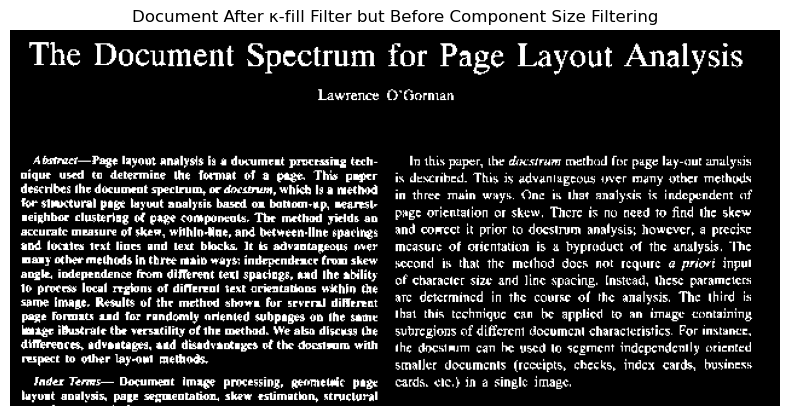

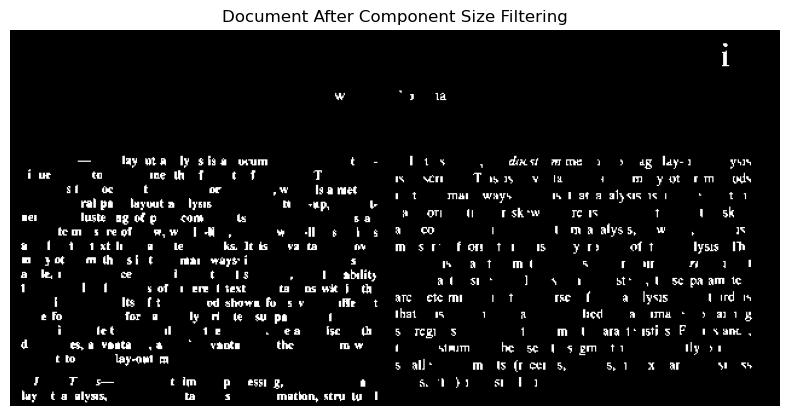

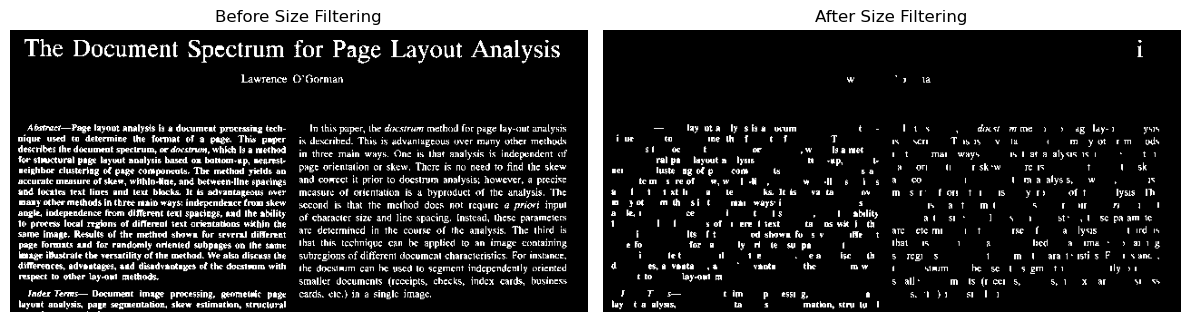

Figures have been created and saved as:
1. before_size_filtering.png - Document after κ-fill but before size filtering
2. after_size_filtering.png - Document after size filtering
3. size_filtering_comparison.png - Side-by-side comparison


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

def create_paper_figures(image_path, kfill_threshold=5, max_iterations=10):
    """
    Create visualization figures for the paper showing the effect of component size filtering.
    
    Args:
        image_path (str): Path to the input document image.
        kfill_threshold (int): k parameter for kfill filter.
        max_iterations (int): Maximum iterations for kfill filter.
    """
    # Load and preprocess the image
    image = cv2.imread(image_path)
    
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Otsu's thresholding
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Invert if needed (assuming text is black)
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)
    
    # Convert to binary format (0 and 1)
    binary = (binary > 0).astype(np.uint8)
    
    # Apply the kFill filter
    filtered_binary = kfill(binary, k=kfill_threshold, max_iterations=max_iterations)
    
    # Create binary image with the format OpenCV expects
    binary_for_cv = (filtered_binary * 255).astype(np.uint8)
    
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_for_cv, connectivity=8)
    
    # Create Component objects for each connected component (skip the background label 0)
    components = []
    for i in range(1, num_labels):
        # Extract bounding box data
        x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        centroid = (centroids[i, 0], centroids[i, 1])
        
        component_mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_length = cv2.arcLength(contours[0], True) if contours else 0
        
        components.append(Component(bbox=(x, y, w, h), centroid=centroid, area=area, contour_length=contour_length))
    
    # Calculate areas
    areas = [comp.area for comp in components]
    
    # Find the peak of the histogram
    hist, bin_edges = np.histogram(areas, bins=50)
    peak_bin_index = np.argmax(hist)
    peak_area = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2
    
    # Set minimum and maximum area thresholds
    min_area = 3  # As per requirements
    max_area = 3 * peak_area  # 3 times the peak area
    
    # Filter components based on area criteria
    filtered_components = [comp for comp in components if min_area <= comp.area <= max_area]
    
    # Create a custom colormap for our filtered binary images (white background, black text)
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['white', 'black'])
    
    # Create the "before filtering" figure showing the document after kfill
    plt.figure(figsize=(8, 10))
    plt.imshow(1 - filtered_binary, cmap=cmap)  # Invert for better visualization (black text on white background)
    plt.title('Document After κ-fill Filter but Before Component Size Filtering')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('before_size_filtering.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a modified binary image with filtered components
    filtered_image = np.zeros_like(filtered_binary)
    for comp in filtered_components:
        x, y, w, h = comp.bbox
        mask = labels[y:y+h, x:x+w] == labels[y+h//2, x+w//2]
        filtered_image[y:y+h, x:x+w] = filtered_binary[y:y+h, x:x+w] * mask
    
    # Create the "after filtering" figure
    plt.figure(figsize=(8, 10))
    plt.imshow(1 - filtered_image, cmap=cmap)  # Inverted for visualization
    plt.title('Document After Component Size Filtering')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('after_size_filtering.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a comparison figure (side by side)
    plt.figure(figsize=(12, 10))
    
    # Before filtering
    plt.subplot(1, 2, 1)
    plt.imshow(1 - filtered_binary, cmap=cmap)
    plt.title('Before Size Filtering')
    plt.axis('off')
    
    # After filtering
    plt.subplot(1, 2, 2)
    plt.imshow(1 - filtered_image, cmap=cmap)
    plt.title('After Size Filtering')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('size_filtering_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figures have been created and saved as:")
    print("1. before_size_filtering.png - Document after κ-fill but before size filtering")
    print("2. after_size_filtering.png - Document after size filtering")
    print("3. size_filtering_comparison.png - Side-by-side comparison")
    
    return filtered_binary, filtered_image, components, filtered_components, removed_components

# Example usage
filtered_binary, filtered_image, all_components, filtered_components, removed_components = create_paper_figures(image_path)

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250


Text(0.5, 1.0, 'Number of Components vs Binarization Threshold Value')

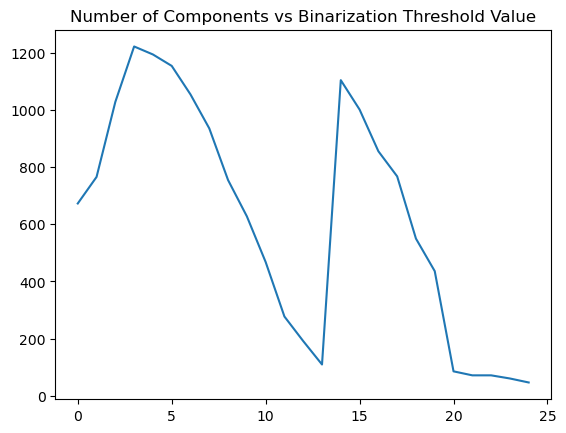

In [23]:
def find_and_filter_components(binary_image):
    """
    Find connected components, calculate their areas, plot a histogram,
    and filter based on the peak of the histogram.
    
    Args:
        binary_image (numpy.ndarray): Binary image (1 for foreground, 0 for background).
        
    Returns:
        list: List of filtered Component objects
        numpy.ndarray: Visualization image with components
    """
    # Make sure the binary image is in the format OpenCV expects (uint8, values 0 or 255)
    binary_for_cv = (binary_image * 255).astype(np.uint8)
    
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_for_cv, connectivity=8)
    
    # Create Component objects for each connected component (skip the background label 0)
    components = []
    for i in range(1, num_labels):
        # Extract bounding box data
        x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        centroid = (centroids[i, 0], centroids[i, 1])
        
        # Instead of contour length, we'll use perimeter
        # Create a mask for this component
        component_mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_length = cv2.arcLength(contours[0], True) if contours else 0
        
        # Create Component object
        components.append(Component(bbox=(x, y, w, h), centroid=centroid, area=area, contour_length=contour_length))
    
    # Extract areas for histogram
    areas = [comp.area for comp in components]
    
    # Plot histogram of component areas
    hist, bin_edges = np.histogram(areas, bins=50)
    # Find the peak of the histogram
    peak_bin_index = np.argmax(hist)
    peak_area = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2
    # Set minimum and maximum area thresholds
    min_area = 3  # As per requirements
    max_area = 3 * peak_area  # 3 times the peak area
    
    # Filter components based on area criteria
    filtered_components = [comp for comp in components if min_area <= comp.area <= max_area]
    
    
    
    return filtered_components

# Assuming you have already run the previous code to get the binary image
# Let's modify your code to incorporate the component analysis:

image = cv2.imread(image_path)

# Convert the image to grayscale first
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#create array of lenght 250

array = np.zeros(25)

for i in range(10, 255, 10):
    print(i)
    t, binary = cv2.threshold(gray, i, 255, cv2.THRESH_BINARY)



    # Invert if needed (assuming text is black)
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)
        
    # Convert to binary format (0 and 1)
    binary = (binary > 0).astype(np.uint8)

    # Apply the Will filter (kFill) for noise reduction
    filtered_binary = kfill(binary, k=kfill_threshold, max_iterations=max_iterations)

    # Find and filter components
    filtered_components = find_and_filter_components(filtered_binary)
    idx = int(i/10) - 1
    array[idx] = len(filtered_components)

plt.plot(array)
plt.title('Number of Components vs Binarization Threshold Value')




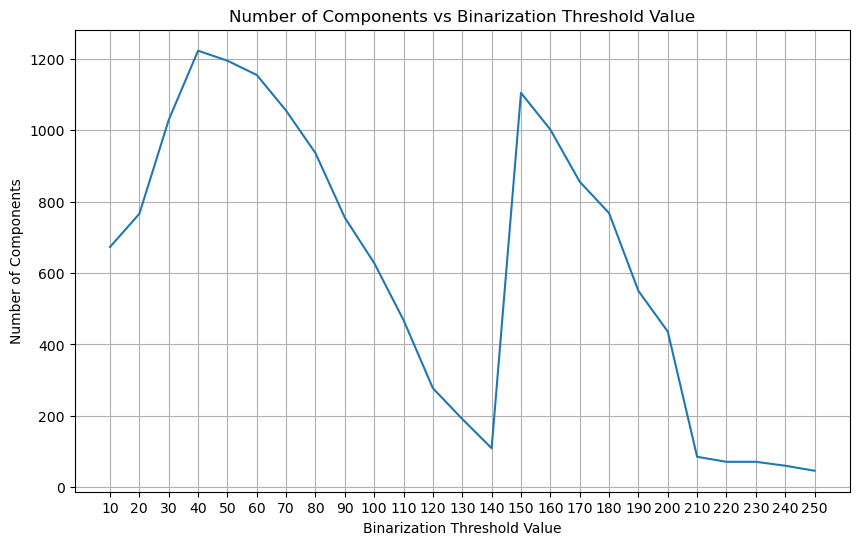

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(array)
plt.title('Number of Components vs Binarization Threshold Value')
plt.xlabel('Binarization Threshold Value')
plt.ylabel('Number of Components')
plt.xticks(np.arange(0, 25, 1), np.arange(10, 260, 10))
plt.grid()
plt.show()

